In [ ]:
# Homework 3
## Statistical Learning and Prediction
#This implements K-Means clustering, K-Nearest Neighbors classification, and Change Point Analysis using Fitbit activity data.

In [2]:
import os
os.listdir()

['.virtualenvs',
 'dailySteps.csv',
 'hourlyIntensities.csv',
 '.local',
 '.ipynb_checkpoints',
 '.pythonstartup.py',
 'dailyCalories.csv',
 '.ipython',
 'minuteCalories.csv',
 'README.ipynb',
 'hourlySteps.csv',
 '.gitconfig',
 '.vimrc',
 'hourlyCalories.csv',
 'dailyIntensities.csv',
 'minuteMETs.csv',
 '.profile',
 'anaconda_projects',
 '.jupyter',
 'HW3.ipynb',
 '.anaconda',
 'minuteSteps.csv',
 '.npm',
 '.conda',
 'minuteIntensities.csv',
 '.bashrc']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def kmeans(X, k, iterations=10):
    # randomly choose k data points as the starting cluster centroids
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    # repeat the clustering process several times to improve cluster placement
    for _ in range(iterations):
        # create an empty list for each cluster
        clusters = [[] for _ in range(k)]

        # go through every point in the dataset
        for point in X:
            # compute the distance from this point to every centroid
            distances = [np.linalg.norm(point - c) for c in centroids]

            # find the centroid with the smallest distance
            cluster_index = np.argmin(distances)

            # assign this point to that cluster
            clusters[cluster_index].append(point)

        # recompute the centroid locations
        new_centroids = []
        for cluster in clusters:
            # if a cluster has points, compute the new centroid as the mean
            if len(cluster) > 0:
                new_centroids.append(np.mean(cluster, axis=0))
            else:
                # if a cluster accidentally becomes empty, keep the old centroid position
                new_centroids.append(centroids[len(new_centroids)])

        # update centroid positions
        centroids = np.array(new_centroids)

    # return both the cluster groups and their centroid locations
    return clusters, centroids

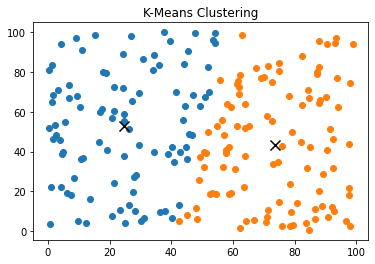

In [6]:
# generate sample data
X = np.random.rand(200,2)*100

clusters, centroids = kmeans(X,2)

# plot
for cluster in clusters:
    cluster = np.array(cluster)
    plt.scatter(cluster[:,0], cluster[:,1])

plt.scatter(centroids[:,0],centroids[:,1],color='black',marker='x',s=100)
plt.title("K-Means Clustering")
plt.show()

In [ ]:
## K-Means Result

K-Means is an unsupervised learning method that groups unlabeled data into
clusters based on similarity. Each point is assigned to the nearest centroid,
and the centroid locations are updated repeatedly until the cluster structure
stabilizes. This behavior is consistent with the lecture discussion of
grouping unlabeled data using centroid distance. 

In [8]:
def knn(train_X, train_y, k, new_point):

    # create a list to store distances and labels
    distances = []

    # compute distance from the new point to every training sample
    for i in range(len(train_X)):

        d = np.linalg.norm(train_X[i] - new_point)

        # store the distance and corresponding label
        distances.append((d, train_y[i]))

    # sort all distances from smallest to largest
    distances.sort(key=lambda x: x[0])

    # select the first k nearest neighbors
    neighbors = distances[:k]

    # extract the labels of these neighbors
    labels = [label for _, label in neighbors]

    # return the most common label among the neighbors
    return max(set(labels), key=labels.count)

In [9]:
train_X = np.array([[2,3],[3,4],[5,6],[7,8],[8,8]])
train_y = np.array(["A","A","B","B","B"])

# new point we want to classify
new_point = np.array([4,5])

# run the knn classifier
prediction = knn(train_X, train_y, 3, new_point)

print("Predicted class:", prediction)

Predicted class: A


In [ ]:
## KNN Result

K-Nearest Neighbors is a supervised learning algorithm because it uses labeled
training data to classify a new point. The class of the new point is determined
by the majority label among its nearest neighbors, which matches the lecture
explanation of using labeled examples for prediction. 

In [10]:
def cpa(x, K=1000):
    # convert to numpy array
    x = np.array(x)

    # subtract mean
    mean_x = np.mean(x)
    epsilon = x - mean_x

    # cumulative sum of errors
    y = np.cumsum(epsilon)

    # range of original signal
    R_original = np.max(y) - np.min(y)

    # change point index
    cp_index = np.argmax(np.abs(y))

    # bootstrap
    R_boot = []
    for _ in range(K):
        shuffled = np.random.permutation(x)
        eps = shuffled - np.mean(shuffled)
        y_boot = np.cumsum(eps)
        R_boot.append(np.max(y_boot) - np.min(y_boot))

    # confidence
    R_boot = np.array(R_boot)
    confidence = np.sum(R_boot < R_original) / K

    return cp_index, confidence

In [11]:
# load dataset
steps = pd.read_csv("dailySteps.csv")

# remove zero-step days (Fitbit not worn)
steps = steps[steps["StepTotal"] > 0]

# extract values
data = steps["StepTotal"].values

In [12]:
cp, conf = cpa(data)

print("Main Change Point:", cp)
print("Confidence:", conf)

Main Change Point: 230
Confidence: 1.0


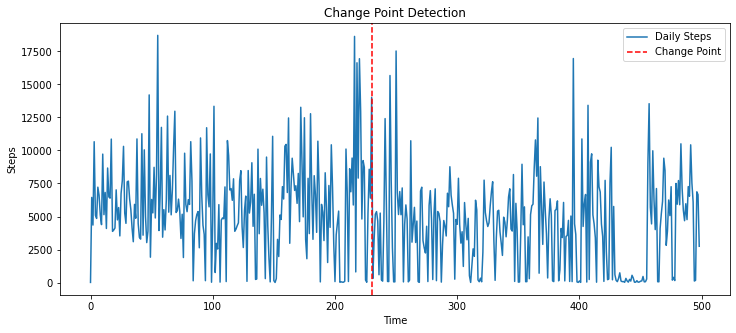

In [13]:
plt.figure(figsize=(12,5))
plt.plot(data, label="Daily Steps")

plt.axvline(cp, color='red', linestyle='--', label="Change Point")

plt.title("Change Point Detection")
plt.xlabel("Time")
plt.ylabel("Steps")
plt.legend()
plt.show()

In [14]:
before = data[:cp]
after = data[cp:]

print("Before Mean:", np.mean(before))
print("After Mean:", np.mean(after))

Before Mean: 5970.947826086956
After Mean: 4105.118959107806
